# Preparing Data for Hybrid Bias Correction

Benny Istanto<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1)<a name="cite_ref-2"></a>[<sup>[2]</sup>](#cite_note-2), Rizaldi Boer<a name="cite_ref-3"></a>[<sup>[3]</sup>](#cite_note-3)<a name="cite_ref-4"></a>[<sup>[4]</sup>](#cite_note-4), I Putu Santikayasa<a name="cite_ref-3"></a>[<sup>[3]</sup>](#cite_note-3)<a name="cite_ref-5"></a>[<sup>[5]</sup>](#cite_note-5)
***

<font size="2"><a name="cite_note-1"></a>1. [^](#cite_ref-1) Applied Climatology Study Program, Graduate School, Bogor Agricultural University<br>
<a name="cite_note-2"></a>2. [^](#cite_ref-2) Geospatial Operations Support Team, Development Economic Data Group, The World Bank<br>
<a name="cite_note-3"></a>3. [^](#cite_ref-3) Department of Geophysics and Meteorology, Faculty of Mathematics and Natural Sciences, Bogor Agricultural University<br>
<a name="cite_note-4"></a>4. [^](#cite_ref-4) International Research Institute for Environment and Climate Change, Bogor Agricultural University<br>
<a name="cite_note-5"></a>5. [^](#cite_ref-5) Center for Climate Risk and Opportunity Management in South East Asia and Pacific, Bogor Agricultural University<br>

# 1 Configuration

Configuration is a crucial aspect of setting up any data analysis or processing workflow. Proper configuration ensures seamless access to data, efficient execution of tasks, and smooth integration of required tools and libraries. This article covers several essential subtopics related to configuration, such as connecting Google Drive to Colab, installing packages, importing libraries, and setting up working directories.

## 1.1 Mounting Google Drive in Colab

To work with files stored in your Google Drive, we first need to mount it into our Colab environment. The code below:

- Flushes any existing mount to avoid conflicts
- Mounts your Drive at `/content/drive`
- Lists the top-level contents so you can confirm everything is accessible

This step is **foundational**—without it, none of the file reads/writes in later sections (e.g. downloading IMERG subsets, saving masks) will work.

>**Notes**
>
>This only applies when running in Google Colab

In [13]:
from google.colab import drive
import os

# If Drive is already mounted, unmount it first to avoid errors
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
        print("✅ Successfully unmounted previous Drive mount")
    except Exception:
        print("⚠️ Unmount failed; it may not have been mounted or is busy")

# Mount your Google Drive
drive.mount('/content/drive')

# Verify by listing the root folder
print("\nContents of /content/drive:")
!ls -1 /content/drive


Successfully unmounted
Mounted at /content/drive


**Troubleshooting:**  
- **Disconnected Runtime:** If Colab becomes disconnected, Reconnect the runtime and rerun the mounting cell.
- **Mountpoint Error:** If we receive an error such as `Mountpoint must not already contain files`, delete all the sub-folders under `/content/drive` from the Files panel before retrying. We need to delete these one by one starting from the innermost folders, until the last "drive" folder is deleted.


**What’s next?**

Once you see your Drive’s folder structure, you’re ready to install any extra packages you need (Section 1.2) and set up your project directories (Section 1.3).

## 1.2 Install Geospatial Dependencies

Google Colab comes pre-installed with numerous Python packages, which can be listed using the `!pip list` command. However, specific projects may require packages not included by default. In such cases, we can install them directly within the Colab environment using `!pip install`.

Before we dive into data processing and visualization, we need to add a few specialized libraries to our Colab environment. The command below:

- Installs **rasterio** for fast, Pythonic raster I/O  
- Adds **netcdf4** so xarray can use its advanced compression support (beyond SciPy’s defaults)  
- Brings in **cartopy** for map projections and plotting  

Having these in place ensures that subsequent steps—reading NetCDF subsets, rasterizing boundaries, and creating publication-quality maps—run without errors.


In [15]:
!pip install rasterio netcdf4 cartopy

Once this completes, you’ll be ready to load and manipulate spatial data (Sections 2.1 and beyond) and visualize your results on real-world map projections.

## 1.3 Defining and Creating Project Folders

Next, we establish a clear folder structure on your mounted Drive so that raw inputs, downloads, intermediate masks, and final outputs each live in their own dedicated directory. The snippet below:

- Declares a single main project folder
- Builds subpaths for input data, downloaded files, mask outputs, and final results
- Ensures each required directory exists, creating it if necessary

A well-organized directory layout makes it easy to trace where every file came from and prevents accidental overwrites—setting you up for a reproducible, scalable workflow.


In [21]:
# Import library
import os

# Configurable Directory
# Base folder on Google Drive for this project
main_dir = '/content/drive/MyDrive/hybrid-bias-correction'

# Define key subfolders
input_dir     = f'{main_dir}/data/input'      # RAW input data goes here
downloads_dir = f'{main_dir}/data/downloads'  # All downloaded files
mask_dir      = f'{main_dir}/data/mask'       # Generated land masks
output_dir    = f'{main_dir}/data/output'     # Final outputs & results

# List of directories to ensure exist
for d in [input_dir, downloads_dir, mask_dir, output_dir]:
    os.makedirs(d, exist_ok=True)
    print(f"✅ Ensured directory exists: {d}")


✅ Ensured directory exists: /content/drive/MyDrive/hybrid-bias-correction/data/input
✅ Ensured directory exists: /content/drive/MyDrive/hybrid-bias-correction/data/downloads
✅ Ensured directory exists: /content/drive/MyDrive/hybrid-bias-correction/data/mask
✅ Ensured directory exists: /content/drive/MyDrive/hybrid-bias-correction/data/output


**What’s next?**

With our workspace now structured, we’ll move on to configuring NASA Earthdata authentication so that we can programmatically fetch IMERG and CPC data (Section 1.4).

## 1.4 Configuring NASA Earthdata Authentication

To programmatically download IMERG and CPC datasets from NASA’s GES DISC THREDDS server, you must authenticate with your Earthdata credentials. The snippet below:

- **Creates** a `.netrc` file containing your username and password

  ```text
  machine urs.earthdata.nasa.gov login {username} password {password}
  ```

- **Moves** that file into `/root/.netrc` so that both `wget` and Python’s `requests` library can automatically pick it up  

Without this step, any attempt to access the NCSS endpoints will fail with an authentication error. Make sure you have:

1. Registered at https://urs.earthdata.nasa.gov/users/new  
2. Approved the “NASA GESDISC DATA ARCHIVE” application via the link provided in your Earthdata account  


In [22]:
import os
import logging

logging.basicConfig(level=logging.INFO)

def create_netrc_file(username: str, password: str):
    """
    Write a .netrc file in the current directory with Earthdata credentials.
    """
    netrc_content = (
        f"machine urs.earthdata.nasa.gov "
        f"login {username} password {password}"
    )
    with open('.netrc', 'w') as f:
        f.write(netrc_content)
    logging.info("✅ .netrc file created in working directory.")

def move_to_colab_root():
    """
    Move the .netrc file to /root so that wget and requests can use it.
    """
    target = '/root/.netrc'
    os.replace('.netrc', target)
    logging.info(f"✅ .netrc file moved to {target}.")

def main():
    try:
        # TODO: replace these with your actual Earthdata credentials
        username = "your_username"
        password = "your_password"

        create_netrc_file(username, password)
        move_to_colab_root()
        print("✅ NASA Earthdata authentication is now configured.")

    except Exception as e:
        logging.error("❌ Failed to configure .netrc: %s", e)
        print("❌ An error occurred. See log for details.")

if __name__ == "__main__":
    main()


✅ NASA Earthdata authentication is now configured.


**What’s next?**

With authentication in place, we can safely issue HTTPS requests to the THREDDS NCSS endpoints (Section 3) and retrieve only the spatial–temporal slices of IMERG or CPC data that you need, without downloading full global archives.


# 2 Area of Interest

Accurate boundary delineation is essential for robust geospatial analysis. In our workflow, the IMERG grid—with its 0.1° spatial resolution—serves as the fundamental reference for all outputs. To maintain consistency between different datasets and ensure reliable spatial analysis, it is crucial to generate a global land mask that exactly conforms to the IMERG grid. This approach guarantees that all output data layers are aligned and comparable.

There are many global country (admin0) boundary datasets used by humanitarian and international development professionals. Some popular examples include:
- [Natural Earth](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-0-countries/)
- [GADM](https://gadm.org/download_world.html)
- [geoBoundaries](https://www.geoboundaries.org/globalDownloads.html)
- [Fieldmaps.io](https://fieldmaps.io/data/adm0)

For this exercise, we will use the global admin0 boundary from Fieldmaps.io to develop a global land mask at 0.1° resolution.

Furthermore, the consistent global land mask is the key starting point for subsequent processes: users can easily clip this mask to their preferred Area of Interest (AOI), which is described in detail in Section 2.2.



## 2.1 Creating a Global Land Mask

Now that our workspace is organized, we’ll generate a world‐wide land mask perfectly aligned to the IMERG 0.1° grid. This mask will underpin **all** later AOI extractions and ensures that every subsequent raster operation uses the same spatial reference.

The code below:

1. **Downloads** a zipped GeoPackage of admin-0 boundaries from Fieldmaps.io  
2. **Extracts** the vector file into our downloads folder  
3. **Defines** a global 0.1° raster grid spanning latitude [–90, 90] and longitude [–180, 180]  
4. **Rasterizes** each country polygon to a mask where land = 1 and water = NaN  
5. **Builds** an xarray DataArray and **saves** it as a NetCDF for downstream use


In [ ]:
# Download and build global land mask
import os
import zipfile
import requests
import geopandas as gpd
import numpy as np
from rasterio import features
from affine import Affine
import xarray as xr

# Get the admin0 in GPKG format
def download_and_extract_gpkg(url: str, extract_dir: str, zip_fname: str = "adm0_polygons.gpkg.zip"):
    """
    Download a zipped GPKG from `url` into `zip_fname` and extract into `extract_dir`.
    """
    try:
        print(f"⏳ Downloading GPKG from {url} …")
        resp = requests.get(url, stream=True)
        resp.raise_for_status()

        # Write to local zip file
        with open(zip_fname, 'wb') as f:
            for chunk in resp.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"✔️ Downloaded to {zip_fname}")

        # Extract
        with zipfile.ZipFile(zip_fname, 'r') as z:
            z.extractall(extract_dir)
        print(f"✔️ Extracted GPKG to {extract_dir}")

    except requests.HTTPError as he:
        raise RuntimeError(f"HTTP error while downloading GPKG: {he}")
    except Exception as e:
        raise RuntimeError(f"Failed to download or extract GPKG: {e}")

# Rasterize the global land polygon
def rasterize_global_land(gpkg_path: str, out_nc: str, resolution: float = 0.1):
    """
    Read country boundaries from `gpkg_path`, rasterize to a global land mask at `resolution`,
    and save to NetCDF `out_nc`.
    """
    try:
        print(f"⏳ Reading country boundaries from {gpkg_path} …")
        gdf = gpd.read_file(gpkg_path)
        print(f"✔️ Loaded {len(gdf)} polygons")

        # Define global grid
        lon_min, lon_max = -180, 180
        lat_min, lat_max = -90, 90
        width = int((lon_max - lon_min) / resolution)
        height = int((lat_max - lat_min) / resolution)
        transform = Affine.translation(lon_min, lat_max) * Affine.scale(resolution, -resolution)
        print(f"✔️ Raster grid: {width}×{height} at {resolution}° resolution")

        # Rasterize: 1=land, NaN=water
        shapes = ((geom, 1) for geom in gdf.geometry)
        mask = features.rasterize(
            shapes,
            out_shape=(height, width),
            transform=transform,
            fill=np.nan,
            dtype="float32",
            all_touched=True
        )
        print("✔️ Rasterization complete")

        # Build xarray DataArray
        lon = lon_min + (np.arange(width) + 0.5) * resolution
        lat = lat_max - (np.arange(height) + 0.5) * resolution
        da = xr.DataArray(mask, coords={'lat': lat, 'lon': lon}, dims=['lat', 'lon'], name='land')
        da.attrs.update({
            "description": "Global land mask (1=land, NaN=water)",
            "grid_resolution": f"{resolution}°",
            "units": "1 / NaN"
        })

        # Save NetCDF
        print(f"⏳ Saving NetCDF to {out_nc} …")
        da.to_netcdf(out_nc)
        print(f"✅ World land mask generated at {out_nc}")

    except Exception as e:
        raise RuntimeError(f"Error during rasterization or saving NetCDF: {e}")

def main():
    try:
        base = '/content/drive/MyDrive/hybrid-bias-correction'
        bdir = os.path.join(base, 'data/downloads/boundary')
        wdir = os.path.join(base, 'data/mask/world')
        os.makedirs(bdir, exist_ok=True)
        os.makedirs(wdir, exist_ok=True)

        gpkg_url = "https://data.fieldmaps.io/adm0/osm/all/adm0_polygons.gpkg.zip"
        download_and_extract_gpkg(gpkg_url, bdir)

        gpkg = os.path.join(bdir, "adm0_polygons.gpkg")
        out_nc = os.path.join(wdir, "wld_land_mask.nc")
        rasterize_global_land(gpkg, out_nc)

        print("🎉 All done: global land mask is ready.")

    except Exception as e:
        print(f"❌ {e}")

# Run
if __name__ == "__main__":
    main()


⏳ Downloading GPKG from https://data.fieldmaps.io/adm0/osm/all/adm0_polygons.gpkg.zip …
✔️ Downloaded to adm0_polygons.gpkg.zip
✔️ Extracted GPKG to /content/drive/MyDrive/hybrid-bias-correction/data/downloads/boundary
⏳ Reading country boundaries from /content/drive/MyDrive/hybrid-bias-correction/data/downloads/boundary/adm0_polygons.gpkg …
✔️ Loaded 329 polygons
✔️ Raster grid: 3600×1800 at 0.1° resolution
✔️ Rasterization complete
⏳ Saving NetCDF to /content/drive/MyDrive/hybrid-bias-correction/data/mask/world/wld_land_mask.nc …
✅ World land mask generated at /content/drive/MyDrive/hybrid-bias-correction/data/mask/world/wld_land_mask.nc
🎉 All done: global land mask is ready.


With this NetCDF now in place, we can move on to Section 2.2 to clip it to any Area of Interest—whether by country code, bounding box, or our own custom shapefile.

## 2.2 AOI Options

Defining a precise Area of Interest (AOI) is crucial for targeted analysis. There are at least three options to obtain the AOI: (1) using publicly available administrative boundaries, (2) using a bounding box or predefined polygon, or (3) using our own data.

Using the global land mask created in Section 2.1, we can clip the world mask to any of these AOIs. The following subsections describe sample workflows for each approach, including scripts to extract the AOI from global administrative boundaries (Section 2.2.1), custom bounding boxes (Section 2.2.2), or user-supplied datasets (Section 2.2.3).

For a smoother experience, we recommend using administrative boundaries from the first option, but we are free to choose whichever option best fits our needs!

By accurately isolating the focus area using one of these methods, we ensure that the data processing is relevant and efficient for specific requirements.

### 2.2.1 Country Boundaries

In this section, we utilize publicly available administrative boundary datasets to select a desired region. This option is often preferred because it provides country boundaries, which are widely used by many humanitarian professionals.

Let’s first check the attributes of the country boundary dataset we have downloaded. This will help us identify the fields containing the ISO3 country code and the country name, which we will use to filter for specific countries.


In [ ]:
# Inspect the GeoPackage attributes
import geopandas as gpd

# Path to your GPKG
gpkg_file = "/content/drive/MyDrive/hybrid-bias-correction/data/downloads/boundary/adm0_polygons.gpkg"

# Read into GeoDataFrame
gdf = gpd.read_file(gpkg_file)

# Print the column names and first few rows
print("Available columns:", list(gdf.columns))
print(gdf.head())


Available columns: ['adm0_id', 'adm0_src', 'adm0_name', 'adm0_name1', 'adm0_name2', 'iso_cd', 'iso_2', 'iso_3', 'iso_3_grp', 'region3_cd', 'region3_nm', 'region2_cd', 'region2_nm', 'region1_cd', 'region1_nm', 'status_cd', 'status_nm', 'wld_date', 'wld_update', 'wld_land', 'wld_view', 'wld_notes', 'geometry']
        adm0_id adm0_src             adm0_name     adm0_name1  adm0_name2  \
0  ABW-20250108      ABW         Aruba (Neth.)          Aruba         NaN   
1  AFG-20250108      AFG           Afghanistan    Afghanistan         NaN   
2  AGO-20250108      AGO                Angola         Angola         NaN   
3  AIA-20250108      AIA         Anguilla (UK)       Anguilla         NaN   
4  ALA-20250108      ALA  Åland Islands (Fin.)  Åland Islands         NaN   

   iso_cd iso_2 iso_3 iso_3_grp  region3_cd  ... region1_cd  region1_nm  \
0     533    AW   ABW       NLD          29  ...         19    Americas   
1       4    AF   AFG       AFG          34  ...        142        Asia   
2 

After inspecting the attributes of the country boundaries, we’ll proceed to filter the data based on the **ISO3** codes `adm0_src` and **Country** names `adm0_name`.

For full list of ISO3 country code, we can refer to this page [https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3).

Once the countries are selected, we can interactively preview them on a map to ensure that the boundaries are correct.

In [1]:
# Interactive preview of selected polygons with Folium
import os
import geopandas as gpd
import folium
from folium.features import GeoJsonPopup

def load_and_filter_gpkg(gpkg_path: str, iso3_list: list):
    print(f"⏳ Loading GPKG from {gpkg_path} …")
    gdf = gpd.read_file(gpkg_path)
    print(f"✔️ Loaded {len(gdf)} features")

    print(f"⏳ Filtering for ISO3 codes: {iso3_list} …")
    gdf_f = gdf[gdf['adm0_src'].isin(iso3_list)].copy()
    print(f"✔️ {len(gdf_f)} features after filtering")

    # Drop any datetime columns (not JSON-serializable)
    dt_cols = gdf_f.select_dtypes(include=['datetime64']).columns
    if len(dt_cols):
        print(f"⏳ Dropping datetime columns: {list(dt_cols)} …")
        gdf_f.drop(columns=dt_cols, inplace=True)
        print("✔️ Datetime columns removed")

    return gdf_f

def build_folium_map(gdf, popup_fields: list, zoom_start: int = 4):
    # Compute map center from bounds
    minx, miny, maxx, maxy = gdf.total_bounds
    center = [(miny + maxy) / 2, (minx + maxx) / 2]
    print(f"⏳ Building Folium map centered at {center} …")

    m = folium.Map(location=center, zoom_start=zoom_start, tiles="CartoDB positron")
    folium.GeoJson(
        gdf,
        name="Filtered Polygons",
        popup=GeoJsonPopup(fields=popup_fields, labels=True),
        style_function=lambda feat: {
            "fillColor": "#228B22",
            "color": "black",
            "weight": 0.7,
            "fillOpacity": 0.3,
        }
    ).add_to(m)

    print("✅ Folium map is ready")
    return m

def main():
    try:
        base = '/content/drive/MyDrive/hybrid-bias-correction'
        gpkg = os.path.join(base, 'data/downloads/boundary/adm0_polygons.gpkg')
        iso3_list = ['LKA', 'IND', 'BGD', 'PAK', 'NPL', 'BTN', 'MDV', 'AFG']
        popup_fields = ['adm0_src', 'adm0_name']

        gdf_filtered = load_and_filter_gpkg(gpkg, iso3_list)
        m = build_folium_map(gdf_filtered, popup_fields, zoom_start=4)

        # In Colab the last expression is displayed automatically:
        return m

    except Exception as e:
        print(f"❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()


⏳ Loading GPKG from /content/drive/MyDrive/hybrid-bias-correction/data/downloads/boundary/adm0_polygons.gpkg …
❌ Error: /content/drive/MyDrive/hybrid-bias-correction/data/downloads/boundary/adm0_polygons.gpkg: No such file or directory


For this exercise, we will use **Sri Lanka** as selected country boundary, with the column `adm0_src` = 'LKA'

In [ ]:
# Generate and save AOI‐specific land mask
import os
import geopandas as gpd
import numpy as np
import xarray as xr
from rasterio import features
from affine import Affine

def load_world_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading world land mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ World land mask loaded")
    return da

def filter_aoi(gpkg_path: str, iso3_code: str) -> gpd.GeoDataFrame:
    print(f"⏳ Loading GPKG from {gpkg_path} …")
    gdf = gpd.read_file(gpkg_path)
    print(f"✔️ Loaded {len(gdf)} features")

    print(f"⏳ Filtering for ISO3 == '{iso3_code}' …")
    gdf_aoi = gdf[gdf['adm0_src'] == iso3_code].copy()
    print(f"✔️ {len(gdf_aoi)} features after filtering")
    return gdf_aoi

def rasterize_and_clip(aoi_gdf: gpd.GeoDataFrame, world_da: xr.DataArray) -> xr.DataArray:
    print("⏳ Rasterizing AOI onto world grid …")
    # prepare shapes
    shapes = ((geom, 1) for geom in aoi_gdf.geometry)

    # grid params
    lon = world_da['lon'].values
    lat = world_da['lat'].values
    res = float(lon[1] - lon[0])
    lon_min = lon.min() - res/2
    lat_max = lat.max() + res/2
    h, w = len(lat), len(lon)
    transform = Affine.translation(lon_min, lat_max) * Affine.scale(res, -res)

    rast = features.rasterize(
        shapes=shapes,
        out_shape=(h, w),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=True
    )

    print("⏳ Clipping world mask to AOI …")
    clipped = np.where(rast == 1, world_da.values, np.nan)

    # subset to bounds
    mask = ~np.isnan(clipped)
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    lat_sub = lat[rows.min():rows.max()+1]
    lon_sub = lon[cols.min():cols.max()+1]
    data_sub = clipped[rows.min():rows.max()+1, cols.min():cols.max()+1]

    da_aoi = xr.DataArray(
        data_sub,
        coords={'lat': lat_sub, 'lon': lon_sub},
        dims=['lat', 'lon'],
        name='land'
    )
    da_aoi.attrs.update({
        'description': f'AOI land mask for {aoi_gdf["adm0_src"].iloc[0]} (1=land, NaN elsewhere)',
        'grid_resolution': f'{res} deg',
        'units': '1 for land, NaN otherwise'
    })
    print("✔️ AOI mask rasterized and clipped")
    return da_aoi

def save_aoi_mask(da: xr.DataArray, out_path: str):
    print(f"⏳ Saving AOI mask to {out_path} …")
    da.to_netcdf(out_path)
    print("✅ AOI land mask saved successfully")

def main():
    try:
        base = '/content/drive/MyDrive/hybrid-bias-correction'
        world_nc = os.path.join(base, 'data/mask/world/wld_land_mask.nc')
        gpkg = os.path.join(base, 'data/downloads/boundary/adm0_polygons.gpkg')
        iso3 = 'LKA'
        out_dir = os.path.join(base, 'data/mask/iso3')
        os.makedirs(out_dir, exist_ok=True)
        out_file = os.path.join(out_dir, 'iso3_land_mask.nc')

        world_da = load_world_mask(world_nc)
        gdf_aoi = filter_aoi(gpkg, iso3)
        da_aoi = rasterize_and_clip(gdf_aoi, world_da)
        save_aoi_mask(da_aoi, out_file)

    except Exception as e:
        print(f"❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()


⏳ Loading world land mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/world/wld_land_mask.nc …
✔️ World land mask loaded
⏳ Loading GPKG from /content/drive/MyDrive/hybrid-bias-correction/data/downloads/boundary/adm0_polygons.gpkg …
✔️ Loaded 329 features
⏳ Filtering for ISO3 == 'LKA' …
✔️ 1 features after filtering
⏳ Rasterizing AOI onto world grid …
⏳ Clipping world mask to AOI …
✔️ AOI mask rasterized and clipped
⏳ Saving AOI mask to /content/drive/MyDrive/hybrid-bias-correction/data/mask/iso3/iso3_land_mask.nc …
✅ AOI land mask saved successfully


Next, we’ll visualize the generated output.

⏳ Loading AOI mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/iso3/iso3_land_mask.nc …
✔️ AOI mask loaded
⏳ Sorting latitudes ascending …
✔️ Latitudes sorted
⏳ Plotting AOI mask …


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


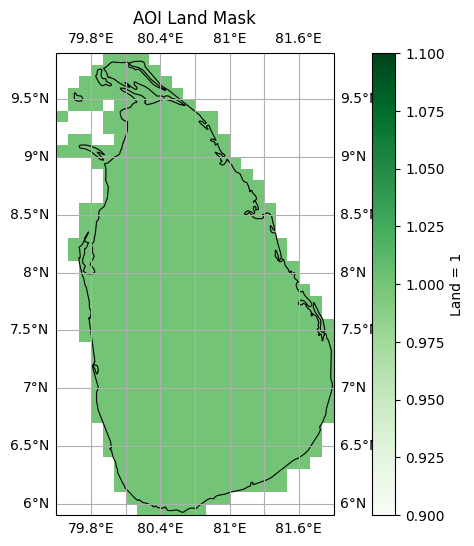

✅ Plot complete


In [ ]:
# Preview AOI land mask with Cartopy
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def load_aoi_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading AOI mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ AOI mask loaded")
    return da

def ensure_lat_ascending(da: xr.DataArray) -> xr.DataArray:
    if da.lat[0] > da.lat[-1]:
        print("⏳ Sorting latitudes ascending …")
        da = da.sortby('lat')
        print("✔️ Latitudes sorted")
    else:
        print("✔️ Latitudes already ascending")
    return da

def plot_mask(da: xr.DataArray):
    print("⏳ Plotting AOI mask …")
    lon = da.lon.values
    lat = da.lat.values
    z = da.values

    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    mesh = ax.pcolormesh(
        lon, lat, z,
        cmap='Greens',
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    cbar = plt.colorbar(mesh, ax=ax, label='Land = 1')
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.gridlines(draw_labels=True)
    ax.set_title("AOI Land Mask")
    plt.show()
    print("✅ Plot complete")

def main():
    try:
        mask_path = '/content/drive/MyDrive/hybrid-bias-correction/data/mask/iso3/iso3_land_mask.nc'
        da_mask = load_aoi_mask(mask_path)
        da_mask = ensure_lat_ascending(da_mask)
        plot_mask(da_mask)
    except Exception as e:
        print(f"❌ Error during preview: {e}")

# Run
if __name__ == "__main__":
    main()


### 2.2.2 Bounding Box/Custom Polygon

In cases where the AOI does not neatly align with country boundaries, we can define it using a bounding box or a custom polygon. This provides more flexibility when working with specific regions that don't correspond to administrative borders.

We’ll walk through how to generate an AOI using a bounding box or a polygon defined by a GeoJSON text from tools such as [geojson.io](https://geojson.io). This method is particularly useful when analyzing non-administrative regions or when the focus area extends beyond country boundaries.

In [ ]:
# Generate and save AOI‐specific land mask from GeoJSON input
import os
import json
import geopandas as gpd
import numpy as np
import xarray as xr
from rasterio import features
from affine import Affine

def load_world_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading world land mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ World land mask loaded")
    return da

def load_aoi_from_geojson(geojson_text: str) -> gpd.GeoDataFrame:
    print("⏳ Parsing AOI from GeoJSON input …")
    try:
        gj = json.loads(geojson_text)
        gdf = gpd.GeoDataFrame.from_features(gj["features"])
        gdf.set_crs("EPSG:4326", inplace=True)
        print(f"✔️ Loaded AOI with {len(gdf)} feature(s)")
        return gdf
    except Exception as e:
        raise RuntimeError(f"Failed to parse GeoJSON: {e}")

def rasterize_and_clip(aoi_gdf: gpd.GeoDataFrame, world_da: xr.DataArray) -> xr.DataArray:
    print("⏳ Rasterizing AOI onto world grid …")
    shapes = ((geom, 1) for geom in aoi_gdf.geometry)

    lon = world_da['lon'].values
    lat = world_da['lat'].values
    res = float(lon[1] - lon[0])
    lon_min = lon.min() - res/2
    lat_max = lat.max() + res/2
    h, w = len(lat), len(lon)
    transform = Affine.translation(lon_min, lat_max) * Affine.scale(res, -res)

    rast = features.rasterize(
        shapes,
        out_shape=(h, w),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=True
    )
    print("✔️ Rasterization complete")

    print("⏳ Clipping world mask to AOI …")
    clipped = np.where(rast == 1, world_da.values, np.nan)

    # subset to data bounds
    mask = ~np.isnan(clipped)
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    lat_sub = lat[rows.min():rows.max()+1]
    lon_sub = lon[cols.min():cols.max()+1]
    data_sub = clipped[rows.min():rows.max()+1, cols.min():cols.max()+1]

    da_aoi = xr.DataArray(
        data_sub,
        coords={'lat': lat_sub, 'lon': lon_sub},
        dims=['lat', 'lon'],
        name='land'
    )
    da_aoi.attrs.update({
        'description': 'AOI land mask from custom GeoJSON (1=land, NaN elsewhere)',
        'grid_resolution': f'{res} deg',
        'units': '1 for land, NaN otherwise'
    })
    print("✔️ AOI mask rasterized and clipped")
    return da_aoi

def save_aoi_mask(da: xr.DataArray, out_path: str):
    print(f"⏳ Saving AOI mask to {out_path} …")
    da.to_netcdf(out_path)
    print("✅ AOI land mask saved successfully")

def main():
    try:
        # --- User parameters ---
        geojson_input = """
        {
          "type": "FeatureCollection",
          "features": [
            {
              "type": "Feature",
              "properties": {},
              "geometry": {
                "type": "Polygon",
                "coordinates": [
                  [
                    [118.59479107734273, -9.01996206314675],
                    [118.59479107734273, -10.672698952161383],
                    [121.2472837636185, -10.672698952161383],
                    [121.2472837636185, -9.01996206314675],
                    [118.59479107734273, -9.01996206314675]
                  ]
                ]
              }
            }
          ]
        }
        """
        base = '/content/drive/MyDrive/hybrid-bias-correction'
        world_nc = os.path.join(base, 'data/mask/world/wld_land_mask.nc')
        bdir = os.path.join(base, 'data/downloads/boundary')
        out_dir = os.path.join(base, 'data/mask/aoi')
        os.makedirs(out_dir, exist_ok=True)
        out_file = os.path.join(out_dir, 'aoi_land_mask.nc')

        # --- Workflow ---
        world_da = load_world_mask(world_nc)
        aoi_gdf = load_aoi_from_geojson(geojson_input)
        da_aoi = rasterize_and_clip(aoi_gdf, world_da)
        save_aoi_mask(da_aoi, out_file)

        print("🎉 AOI land mask generation complete.")

    except Exception as e:
        print(f"❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()


⏳ Loading world land mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/world/wld_land_mask.nc …
✔️ World land mask loaded
⏳ Parsing AOI from GeoJSON input …
✔️ Loaded AOI with 1 feature(s)
⏳ Rasterizing AOI onto world grid …
✔️ Rasterization complete
⏳ Clipping world mask to AOI …
✔️ AOI mask rasterized and clipped
⏳ Saving AOI mask to /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/aoi_land_mask.nc …
✅ AOI land mask saved successfully
🎉 AOI land mask generation complete.


Next, we’ll visualize the generated output.

⏳ Loading AOI mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/aoi_land_mask.nc …
✔️ AOI mask loaded
⏳ Sorting latitudes ascending …
✔️ Latitudes sorted
⏳ Plotting AOI mask …


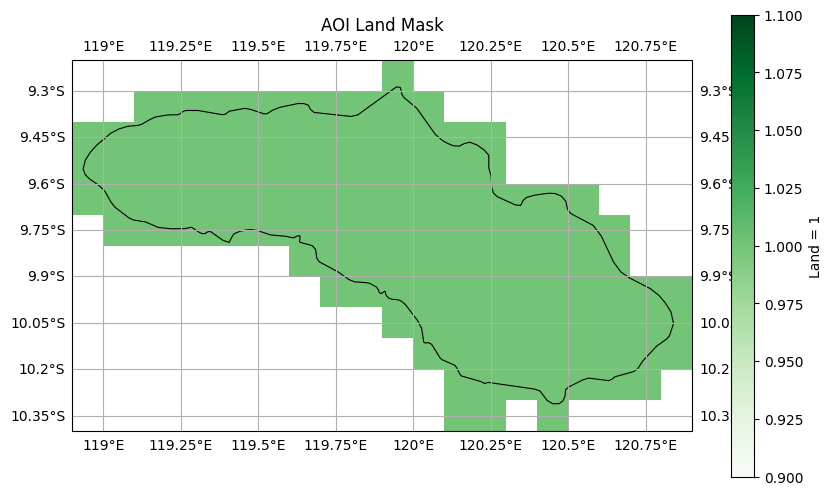

✅ Plot complete


In [ ]:
# Preview AOI land mask with Cartopy
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def load_aoi_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading AOI mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ AOI mask loaded")
    return da

def ensure_lat_ascending(da: xr.DataArray) -> xr.DataArray:
    if da.lat[0] > da.lat[-1]:
        print("⏳ Sorting latitudes ascending …")
        da = da.sortby('lat')
        print("✔️ Latitudes sorted")
    else:
        print("✔️ Latitudes already ascending")
    return da

def plot_mask(da: xr.DataArray):
    print("⏳ Plotting AOI mask …")
    lon = da.lon.values
    lat = da.lat.values
    z = da.values

    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    mesh = ax.pcolormesh(
        lon, lat, z,
        cmap='Greens',
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    cbar = plt.colorbar(mesh, ax=ax, label='Land = 1')
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.gridlines(draw_labels=True)
    ax.set_title("AOI Land Mask")
    plt.show()
    print("✅ Plot complete")

def main():
    try:
        mask_path = '/content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/aoi_land_mask.nc'
        da_mask = load_aoi_mask(mask_path)
        da_mask = ensure_lat_ascending(da_mask)
        plot_mask(da_mask)
    except Exception as e:
        print(f"❌ Error during preview: {e}")

# Run
if __name__ == "__main__":
    main()


### 2.2.3 User-Supplied Data

For those who have their own custom data, this option allows us to define the AOI using shapefiles, GeoJSON, or GeoPackages. This approach is especially useful for projects with non-standard administrative divisions or custom region definitions.

In this section, we describe how to load and process user-supplied vector data. Once loaded, we can rasterize the AOI to match the global land mask and proceed with further spatial analysis.

In [ ]:
# Generate and save AOI‐specific land mask from user‐provided vector
import os
import geopandas as gpd
import numpy as np
import xarray as xr
from rasterio import features
from affine import Affine

def load_world_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading world land mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ World land mask loaded")
    return da

def load_aoi(aoi_path: str) -> gpd.GeoDataFrame:
    """
    Reads a user‐provided AOI vector. Supported formats: .shp, .gpkg, .geojson
    """
    print(f"⏳ Loading AOI from {aoi_path} …")
    gdf = gpd.read_file(aoi_path)
    print(f"✔️ Loaded {len(gdf)} feature(s) from AOI")
    return gdf

def rasterize_and_clip(aoi_gdf: gpd.GeoDataFrame, world_da: xr.DataArray) -> xr.DataArray:
    print("⏳ Rasterizing AOI onto world grid …")
    shapes = ((geom, 1) for geom in aoi_gdf.geometry)

    lon = world_da['lon'].values
    lat = world_da['lat'].values
    res = float(lon[1] - lon[0])
    lon_min = lon.min() - res/2
    lat_max = lat.max() + res/2
    h, w = len(lat), len(lon)
    transform = Affine.translation(lon_min, lat_max) * Affine.scale(res, -res)

    rast = features.rasterize(
        shapes=shapes,
        out_shape=(h, w),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=True
    )

    print("⏳ Clipping world mask to AOI …")
    clipped = np.where(rast == 1, world_da.values, np.nan)

    mask = ~np.isnan(clipped)
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    lat_sub = lat[rows.min():rows.max()+1]
    lon_sub = lon[cols.min():cols.max()+1]
    data_sub = clipped[rows.min():rows.max()+1, cols.min():cols.max()+1]

    da_aoi = xr.DataArray(
        data_sub,
        coords={'lat': lat_sub, 'lon': lon_sub},
        dims=['lat', 'lon'],
        name='land'
    )
    da_aoi.attrs.update({
        'description': 'AOI land mask (1=land, NaN elsewhere)',
        'grid_resolution': f'{res} deg',
        'units': '1 for land, NaN otherwise'
    })
    print("✔️ AOI mask rasterized and clipped")
    return da_aoi

def save_aoi_mask(da: xr.DataArray, out_path: str):
    print(f"⏳ Saving AOI mask to {out_path} …")
    da.to_netcdf(out_path)
    print("✅ AOI land mask saved successfully")

def main():
    try:
        base = '/content/drive/MyDrive/hybrid-bias-correction'
        world_nc = os.path.join(base, 'data/mask/world/wld_land_mask.nc')

        # === USER INPUT ===
        # Place your AOI file (shapefile, gpkg, or geojson) under data/downloads/userdata/
        # e.g. aoi_filename = 'my_region.geojson'
        userdata_dir = os.path.join(base, 'data/downloads/userdata')
        aoi_filename = 'java.shp'  # ← change to your file name
        aoi_path = os.path.join(userdata_dir, aoi_filename)
        # ==================

        out_dir = os.path.join(base, 'data/mask/aoi')
        os.makedirs(out_dir, exist_ok=True)
        out_file = os.path.join(out_dir, 'user_land_mask.nc')

        world_da = load_world_mask(world_nc)
        aoi_gdf = load_aoi(aoi_path)
        da_aoi = rasterize_and_clip(aoi_gdf, world_da)
        save_aoi_mask(da_aoi, out_file)

    except Exception as e:
        print(f"❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()


⏳ Loading world land mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/world/wld_land_mask.nc …
✔️ World land mask loaded
⏳ Loading AOI from /content/drive/MyDrive/hybrid-bias-correction/data/downloads/userdata/java.shp …
✔️ Loaded 6 feature(s) from AOI
⏳ Rasterizing AOI onto world grid …
⏳ Clipping world mask to AOI …
✔️ AOI mask rasterized and clipped
⏳ Saving AOI mask to /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/user_land_mask.nc …
✅ AOI land mask saved successfully


Next, we’ll visualize the generated output.

⏳ Loading AOI mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/user_land_mask.nc …
✔️ AOI mask loaded
⏳ Sorting latitudes ascending …
✔️ Latitudes sorted
⏳ Plotting AOI mask …


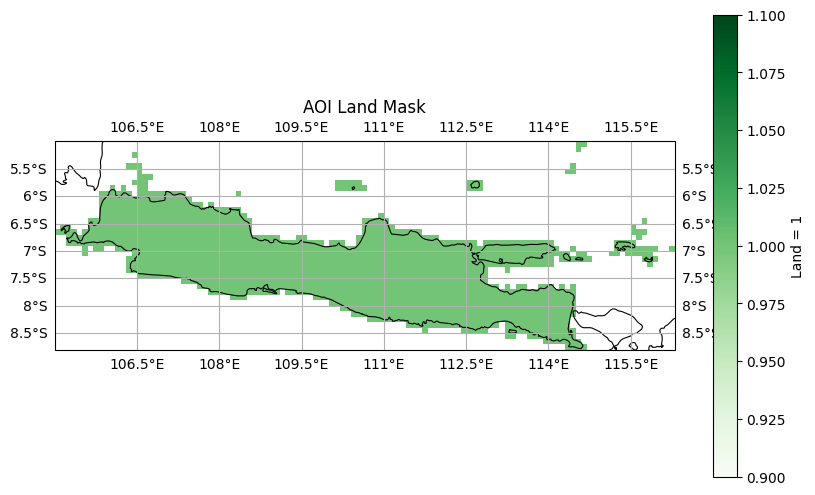

✅ Plot complete


In [ ]:
# Preview AOI land mask with Cartopy
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def load_aoi_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading AOI mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ AOI mask loaded")
    return da

def ensure_lat_ascending(da: xr.DataArray) -> xr.DataArray:
    if da.lat[0] > da.lat[-1]:
        print("⏳ Sorting latitudes ascending …")
        da = da.sortby('lat')
        print("✔️ Latitudes sorted")
    else:
        print("✔️ Latitudes already ascending")
    return da

def plot_mask(da: xr.DataArray):
    print("⏳ Plotting AOI mask …")
    lon = da.lon.values
    lat = da.lat.values
    z = da.values

    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    mesh = ax.pcolormesh(
        lon, lat, z,
        cmap='Greens',
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    cbar = plt.colorbar(mesh, ax=ax, label='Land = 1')
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.gridlines(draw_labels=True)
    ax.set_title("AOI Land Mask")
    plt.show()
    print("✅ Plot complete")

def main():
    try:
        mask_path = '/content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/user_land_mask.nc'
        da_mask = load_aoi_mask(mask_path)
        da_mask = ensure_lat_ascending(da_mask)
        plot_mask(da_mask)
    except Exception as e:
        print(f"❌ Error during preview: {e}")

# Run
if __name__ == "__main__":
    main()


# 3 Data Acquisition

In this section, we’ll obtain the two core datasets needed for our hybrid bias correction:

1. **IMERG Late Run** satellite rainfall estimates from NASA’s GES DISC https://gpm.nasa.gov/data/imerg

2. **CPC-UNI** gauge-based daily precipitation from NOAA PSL https://psl.noaa.gov/data/gridded/data.cpc.globalprecip.html

Optionally we could also download

3. **IMERG Final Run** - to compare how good the corrected IMERG Late Run from the official (Final) version.


Rather than downloading hundreds of gigabytes of global files (2001–2024), we use NASA’s THREDDS NetCDF Subset Service ([NCSS](https://docs.unidata.ucar.edu/tds/current/userguide/netcdf_subset_service_ref.html)) to pull only the spatial–temporal slice corresponding to our AOI.  The THREDDS server exposes annual aggregation files at URLs of the form:  

**IMERG Late Run**
```
https://gpm1.gesdisc.eosdis.nasa.gov/thredds/ncss/grid/aggregation/GPM_3IMERGDL.07/GPM_3IMERGDL.07_Aggregation_{year}.ncml.ncml
```

**IMERG Final Run**
```
https://gpm1.gesdisc.eosdis.nasa.gov/thredds/ncss/grid/aggregation/GPM_3IMERGDF.07/GPM_3IMERGDF.07_Aggregation_{year}.ncml.ncml
```

By supplying query parameters for the precipitation variable, north/west/south/east bounds, horizontal stride, and start/end timestamps, we instruct the server to return a much smaller NetCDF4‑classic subset rather than the full global field. This approach drastically reduces download volume and speeds up data access for any arbitrary bounding box.

The following code first computes a buffered bounding box around our `user_land_mask.nc` so that every IMERG request is confined to exactly the region we care about.

We’ll calculate the buffered bounding box from our AOI mask. This script:

- Loads the AOI land mask
- Identifies the min/max latitude and longitude of all land pixels
- Expands each side by a configurable buffer (e.g. 0.5°)
- Prints out the `north`, `south`, `west`, and `east` values for use in subsequent download requests

Once we have these parameters, we’re ready to loop over each year and grab only the subset of IMERG data we need.

In [6]:
# Calculate buffered bounding box from AOI land mask
import os
import numpy as np
import xarray as xr

def load_aoi_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading AOI land mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ AOI land mask loaded")
    return da

def calculate_bbox(da: xr.DataArray, buffer: float = 0.5):
    """
    Compute the bounding box of non-NaN mask cells and expand each side by `buffer` degrees.
    Returns (north, south, west, east).
    """
    # build 2D arrays of each point's lat/lon
    lats, lons = np.meshgrid(da['lat'].values,
                             da['lon'].values,
                             indexing='ij')
    mask = ~np.isnan(da.values)
    if not mask.any():
        raise ValueError("AOI mask contains no land pixels.")

    # pull out only the lat/lon values where mask is True
    lat_masked = lats[mask]
    lon_masked = lons[mask]

    # compute raw mins/maxs and apply buffer
    south = lat_masked.min() - buffer
    north = lat_masked.max() + buffer
    west  = lon_masked.min() - buffer
    east  = lon_masked.max() + buffer

    # clip latitude to [-90, 90]
    south = max(south, -90.0)
    north = min(north,  90.0)

    # normalize longitudes to [-180, +180]
    west = ((west + 180) % 360) - 180
    east = ((east + 180) % 360) - 180

    # if your region actually crosses the dateline, you may
    # end up with east < west; in that case you can handle
    # it specially (e.g. split into two ranges) —
    # but for most AOIs this is sufficient.

    return north, south, west, east

def main():
    try:
        base = '/content/drive/MyDrive/hybrid-bias-correction'
        mask_path = os.path.join(base, 'data/mask/aoi/user_land_mask.nc')
        da_aoi = load_aoi_mask(mask_path)
        north, south, west, east = calculate_bbox(da_aoi, buffer=0.5)

        print("\n# ===== User Parameters =====")
        print(f"north = {north}   # maximum latitude")
        print(f"south = {south}   # minimum latitude")
        print(f"west  = {west}   # minimum longitude")
        print(f"east  = {east}   # maximum longitude\n")

    except Exception as e:
        print(f"❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()


⏳ Loading AOI land mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/user_land_mask.nc …
✔️ AOI land mask loaded

# ===== User Parameters =====
north = -4.550000000000011   # maximum latitude
south = -9.25   # minimum latitude
west  = 104.55000000000001   # minimum longitude
east  = 116.75   # maximum longitude



## 3.1 Downloading IMERG Late Run (GPM_3IMERGDL)

The following code will download the IMERG-L from the GES DISC using predefined query. With our bounding box defined above, we construct a yearly loop that:

- Builds the THREDDS NCSS URL for each calendar year
- Supplies the precipitation variable, spatial bounds, and start/end timestamps
- Streams a NetCDF4-classic file for each year into our `/data/downloads/GPM_3IMERGDL_subset` folder

> **NOTE**
>
> To understand correctly how the URL and Query are build, lets access this link [NetCDF Subset Service for Grids](https://gpm1.gesdisc.eosdis.nasa.gov/thredds/ncss/grid/aggregation/GPM_3IMERGDL.07/GPM_3IMERGDL.07_Aggregation_2000.ncml.ncml/dataset.html) with Dataset: `/thredds/ncss/grid/aggregation/GPM_3IMERGDL.07/GPM_3IMERGDL.07_Aggregation_2000.ncml.ncml` then choose and adjust some parameters:
> - Variables
> - Horizontal subset
> - Time subset
> - Vertical subset
> - Output format
> - CF compliance
>
> We will get the full NCSS request URL at the bottom. Those URL are use to build the loop for downloading multi year data.


### Step 1: Download process

This approach drastically reduces download volume and ensures that we only fetch the pixels and dates relevant to our AOI.

In [20]:
import requests
from datetime import datetime, timedelta
import os

# ===== User Parameters =====
# We may choose GPM_3IMERGDF for Final or GPM_3IMERGDL for Late Run
product_name = 'GPM_3IMERGDL'

# Bounding box (modify as needed)
north = -4.55   # maximum latitude
south = -9.25   # minimum latitude
west  = 104.55  # minimum longitude
east  = 116.75  # maximum longitude

# Date range (inclusive)
start_date_str = "2001-01-01"
end_date_str   = "2024-12-31"

# Convert to datetime objects
start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
end_date   = datetime.strptime(end_date_str,   "%Y-%m-%d")

# Optional: Horizontal stride (set to 1 for no skipping)
horiz_stride = 1

"""
IMERG v7, the latest version of the Integrated Multi-satellitE Retrievals for GPM,
offers two key variables for analyzing precipitation data from the THREDDS:
 - "precipitation" which is the merged satellite-gauge precipitation estimate.
 - "MWprecipitation" which represents microwave-only precipitation estimates.
"""
# Define the variable name (e.g., "precipitation")
variable = "precipitation"

# Output directory
output_dir = (
    f"/content/drive/MyDrive/hybrid-bias-correction/"
    f"data/downloads/{product_name}_subset"
)
os.makedirs(output_dir, exist_ok=True)

def year_bounds(year, start_date, end_date):
    """
    Return the (t0, t1) window for this calendar year slice.
    """
    t0 = start_date if year == start_date.year else datetime(year, 1, 1)
    t1 = end_date   if year == end_date.year   else datetime(year, 12, 31)
    return t0, t1

for yr in range(start_date.year, end_date.year + 1):
    t0, t1 = year_bounds(yr, start_date, end_date)

    # Exclusive end‐time = midnight of the day AFTER t1
    end_dt = (t1 + timedelta(days=1))
    time_start = t0.strftime("%Y-%m-%dT00:00:00Z")
    time_end   = end_dt.strftime("%Y-%m-%dT00:00:00Z")

    # Per-year NCML aggregation URL
    base_url = (
        f"https://gpm1.gesdisc.eosdis.nasa.gov/thredds/ncss/"
        f"grid/aggregation/{product_name}.07/"
        f"{product_name}.07_Aggregation_{yr}.ncml.ncml"
    )

    # Build Query parameters
    params = {
        "var":         variable,
        "north":       f"{north:.3f}",
        "west":        f"{west:.3f}",
        "east":        f"{east:.3f}",
        "south":       f"{south:.3f}",
        "addLatLon":   "true",
        "horizStride": horiz_stride,
        "time_start":  time_start,
        "time_end":    time_end,
        "accept":      "netcdf4-classic"
    }

    fname = f"{product_name}_subset_{t0.strftime('%Y%m%d')}_{t1.strftime('%Y%m%d')}.nc4"
    outpath = os.path.join(output_dir, fname)

    print(f"Downloading {yr}: {time_start} → {time_end} …")
    r = requests.get(base_url, params=params, stream=True)
    if r.status_code == 200:
        with open(outpath, 'wb') as f:
            for chunk in r.iter_content(1024):
                if chunk:
                    f.write(chunk)
        print(f" ✔ Saved → {fname}")
    else:
        print(f" ❌ Failed {yr}: HTTP {r.status_code} → {r.url}")

print("All done.")


 ✔ Saved → GPM_3IMERGDL_subset_20010101_20011231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20020101_20021231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20030101_20031231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20040101_20041231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20050101_20051231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20060101_20061231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20070101_20071231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20080101_20081231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20090101_20091231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20100101_20101231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20110101_20111231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20120101_20121231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20130101_20131231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20140101_20141231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20150101_20151231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20160101_20161231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20170101_20171231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20180101_20181231.nc4
 ✔ Saved → GPM_3IMERGDL_subset_20190101_201912

You can also use this exact same loop to grab the official IMERG Final Run—simply set `product_name = 'GPM_3IMERGDF'` (and adjust your output folder to `/data/downloads/GPM_3IMERGDF_subset`) so that later on we can compare our bias-corrected IMERG-L against the standard Final Run.

### Step 2: Extract and Subset Variable

This script extract variable `precipitation` and clip using mask data, also add compression to the output to reduce file size.

In [ ]:
import xarray as xr
import os
import glob
from tqdm import tqdm
import pandas as pd

# Main directory on Google Drive
dir = f'/content/drive/MyDrive/exercises/gfm1609'

# Define the input and output directories
#input_dir = f'{dir}/data/downloads/GPM_3IMERGDF' # Final Run
input_dir = f'{dir}/data/downloads/GPM_3IMERGDL' # Late Run
#output_dir = f'{dir}/data/precip/imerg/fdd_1day' # Final Run
output_dir = f'{dir}/data/precip/imerg/ldd_1day' # Late Run#
mask_file = f'{dir}/data/subset/iso3/idn_subset.nc'

# Define the start and end year for processing
start_year = 2005
end_year = 2005

# Check if input folder exists
if not os.path.exists(input_dir):
    print(f"Input folder does not exist: {input_dir}")
    exit(1)

# Create the output directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

# Load the mask dataset
mask_ds = xr.open_dataset(mask_file)
land_mask = mask_ds['land'].astype(float)

# Global variable to store user's choice
user_choice = None

def set_user_decision():
    """Prompt user for decision on existing files and store it globally."""
    global user_choice
    if user_choice is None:
        decision = input("An output file already exists. Choose an action - Replace (R), Skip (S), Abort (A): ").upper()
        while decision not in ['R', 'S', 'A']:
            print("Invalid choice. Please choose again.")
            decision = input("Choose an action - Replace (R), Skip (S), Abort (A): ").upper()
        user_choice = decision

# Create a list of files
#file_list = sorted(glob.glob(os.path.join(input_dir, "3B-DAY.MS.MRG.3IMERG.*.nc4"))) # Final Run
file_list = sorted(glob.glob(os.path.join(input_dir, "3B-DAY-L.MS.MRG.3IMERG.*.nc4"))) # Late Run

# Filter files based on the start and end year
filtered_file_list = [
    f for f in file_list
    if start_year <= int(f.split('.')[4][:4]) <= end_year
]

# Function to process a single file and extract the date
def process_file(file_path):
    ds = xr.open_dataset(file_path)
    date_str = file_path.split('.')[4][:8]  # Extract only the YYYYMMDD part
    date = pd.to_datetime(date_str, format="%Y%m%d")
    ds = ds.assign_coords(time=("time", [date]))  # Update the time coordinate
    ds = ds[['precipitation']]  # Select only the 'precipitation' variable

    # Subset the dataset to match the spatial extent of the mask
    ds = ds.sel(lat=slice(land_mask.lat.min(), land_mask.lat.max()), lon=slice(land_mask.lon.min(), land_mask.lon.max()))

    # Align the mask with the precipitation data
    land_mask_interp = land_mask.interp(lat=ds.lat, lon=ds.lon, method="nearest")

    # Apply the mask
    ds = ds.where(land_mask_interp == 1, drop=True)

    return ds

# Process all files and save them as new nc4 files with compression
for file_path in tqdm(filtered_file_list, desc="Processing daily files"):
    ds = process_file(file_path)
    date_str = file_path.split('.')[4][:8]  # Extract only the YYYYMMDD part
    #output_filename = f"idn_cli_imerg_fdd_1day_{date_str}.nc4" # Final Run
    output_filename = f"idn_cli_imerg_ldd_1day_{date_str}.nc4" # Late Run
    output_filepath = os.path.join(output_dir, output_filename)

    if os.path.exists(output_filepath):
        if user_choice is None:
            set_user_decision()
        if user_choice == 'S':
            print(f"Skipping existing file: {output_filepath}")
            continue  # Skip to the next file
        elif user_choice == 'A':
            print("Aborting process.")
            exit(0)  # Exit the script
        elif user_choice == 'R':
            pass  # Replace the file

    try:
        # Specify compression settings
        comp = dict(zlib=True, complevel=5)
        encoding = {var: comp for var in ds.data_vars}

        ds.attrs['Conventions'] = 'CF-1.8'
        ds.to_netcdf(output_filepath, encoding=encoding, engine='netcdf4')
        print(f"Saved: {output_filepath}")
    except Exception as e:
        print(f"Error saving file {output_filepath}: {e}")

print("Daily processing complete.")


Processing daily files:   0%|          | 0/365 [00:00<?, ?it/s]

An output file already exists. Choose an action - Replace (R), Skip (S), Abort (A): R


Processing daily files:   0%|          | 1/365 [01:01<6:15:19, 61.87s/it]

Saved: /content/drive/MyDrive/exercises/gfm1609/data/precip/imerg/ldd_1day/idn_cli_imerg_ldd_1day_20050101.nc4


Processing daily files:   1%|          | 2/365 [01:05<2:47:28, 27.68s/it]

...

Saved: /content/drive/MyDrive/exercises/gfm1609/data/precip/imerg/ldd_1day/idn_cli_imerg_ldd_1day_20051229.nc4


Processing daily files: 100%|█████████▉| 364/365 [24:02<00:03,  3.51s/it]

Saved: /content/drive/MyDrive/exercises/gfm1609/data/precip/imerg/ldd_1day/idn_cli_imerg_ldd_1day_20051230.nc4


Processing daily files: 100%|██████████| 365/365 [24:04<00:00,  3.96s/it]

Saved: /content/drive/MyDrive/exercises/gfm1609/data/precip/imerg/ldd_1day/idn_cli_imerg_ldd_1day_20051231.nc4
Daily processing complete.


### Step 3: Combine dataset by year for Bias Correction input

This script combine the clipped precipitation data files from the IMERG dataset by year, creating one NetCDF file per year containing daily time series data. And save to a designated folder for the Bias Correction process. It prompts the user to decide whether to replace, skip, or abort if the destination file already exists. The script processes yearly data files from 2001 to 2023, ensuring all relevant files are copied to the specified location for further analysis.

In [ ]:
import xarray as xr
import os
import glob
from tqdm import tqdm
import pandas as pd

# Main directory on Google Drive
dir = f'/content/drive/MyDrive/exercises/gfm1609'

# Define the input and output directories
input_dir = f'{dir}/data/precip/imerg/ldd_1day'  # Input directory for daily NetCDF files
#output_dir = f'{dir}/data/bc/input/imergf'  # Final Run
output_dir = f'{dir}/data/bc/input/imergl'  # Late Run

# Create the output directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

# Create a list of files
#file_list = sorted(glob.glob(os.path.join(input_dir, "idn_cli_imerg_fdd_1day_*.nc4"))) # Final Run
file_list = sorted(glob.glob(os.path.join(input_dir, "idn_cli_imerg_ldd_1day_*.nc4"))) # Late Run

# Group files by year
files_by_year = {}
for file_path in file_list:
    date_str = file_path.split('_')[-1].split('.')[0]
    year = date_str[:4]
    if int(year) >= 2005 and int(year) <= 2005:  # Process only files from 2001 to 2023
        if year not in files_by_year:
            files_by_year[year] = []
        files_by_year[year].append(file_path)

# Global variable to store user's choice
user_choice = None

def set_user_decision():
    """Prompt user for decision on existing files and store it globally."""
    global user_choice
    if user_choice is None:
        decision = input("An output file already exists. Choose an action - Replace (R), Skip (S), Abort (A): ").upper()
        while decision not in ['R', 'S', 'A']:
            print("Invalid choice. Please choose again.")
            decision = input("Choose an action - Replace (R), Skip (S), Abort (A): ").upper()
        user_choice = decision

# Function to process and combine files for a single year
def combine_files_for_year(year, year_files):
    datasets = []
    for file_path in year_files:
        try:
            ds = xr.open_dataset(file_path)
            # Transform from time, lon, lat to time, lat, lon
            ds = ds.transpose('time', 'lat', 'lon')
            datasets.append(ds)
        except Exception as e:
            print(f"Error opening dataset {file_path}: {e}")
            continue

    if datasets:
        combined_ds = xr.concat(datasets, dim="time")
        combined_ds = combined_ds.sortby('time')

        # Define the output file path
        #output_filepath = os.path.join(output_dir, f"idn_imergf_{year}.nc4") # Final Run
        output_filepath = os.path.join(output_dir, f"idn_imergl_{year}.nc4") # Late Run

        if os.path.exists(output_filepath):
            if user_choice is None:
                set_user_decision()
            if user_choice == 'S':
                print(f"Skipping existing file: {output_filepath}")
                return  # Skip to the next file
            elif user_choice == 'A':
                print("Aborting process.")
                exit(0)  # Exit the script
            elif user_choice == 'R':
                pass  # Replace the file

        # Specify compression settings
        comp = dict(zlib=True, complevel=5)
        encoding = {var: comp for var in combined_ds.data_vars}

        # Save the combined dataset to a NetCDF file with CF conventions
        combined_ds.attrs['Conventions'] = 'CF-1.8'
        combined_ds.to_netcdf(output_filepath, encoding=encoding, engine='netcdf4')
        print(f"Saved combined dataset for year {year} to {output_filepath}")

        # Close datasets to free memory
        combined_ds.close()
        for ds in datasets:
            ds.close()

# Combine files for each year
for year, year_files in tqdm(files_by_year.items(), desc="Combining files by year"):
    combine_files_for_year(year, year_files)

print("Yearly combination complete.")


Combining files by year:   0%|          | 0/1 [00:00<?, ?it/s]

An output file already exists. Choose an action - Replace (R), Skip (S), Abort (A): R


Combining files by year: 100%|██████████| 1/1 [2:08:18<00:00, 7698.48s/it]

Saved combined dataset for year 2005 to /content/drive/MyDrive/exercises/gfm1609/data/bc/input/imergl/idn_imergl_2005.nc4
Yearly combination complete.


### Step 3: Generating 2-day, 3-day, 4-day, and 5-day rolling accumulations

This script calculates rolling accumulations for 2-day, 3-day, 4-day, and 5-day periods from the daily `precipitation` data. It loads the previously processed daily files, computes the rolling sums, and saves each accumulated dataset with a filename reflecting the last date of the accumulation period. This step is essential for understanding precipitation trends over multiple days.

In [ ]:
import xarray as xr
import numpy as np
import os
import glob
from tqdm import tqdm
import pandas as pd

# Main directory
dir = f'/content/drive/MyDrive/exercises/gfm1609'

# Define the rolling day output directories
rolling_days = [2, 3, 4, 5]
#input_dir = f'{dir}/data/precip/imerg/fdd_1day' # Final Run
input_dir = f'{dir}/data/precip/imerg/ldd_1day' # Late Run
#combined_ds_filepath = f'{dir}/data/precip/imerg/combined_daily_ds/idn_cli_imerg_fdd_1day_2000_2023.nc4' # Final Run
combined_ds_filepath = f'{dir}/data/precip/imerg/combined_daily_ds/idn_cli_imerg_ldd_1day_2000_2023.nc4' # Late Run
rolling_sum_dir = f'{dir}/data/precip/imerg/combined_daily_ds'

# Check if input folder exists
if not os.path.exists(input_dir):
    print(f"Input folder does not exist: {input_dir}")
    exit(1)

# Create the combined dataset directory if it doesn't exist
os.makedirs(os.path.dirname(combined_ds_filepath), exist_ok=True)
os.makedirs(rolling_sum_dir, exist_ok=True)

# Global variable to store user's choice
user_choice = None

def set_user_decision():
    """Prompt user for decision on existing files and store it globally."""
    global user_choice
    if user_choice is None:
        decision = input("An output file already exists. Choose an action - Replace (R), Skip (S), Abort (A): ").upper()
        while decision not in ['R', 'S', 'A']:
            print("Invalid choice. Please choose again.")
            decision = input("Choose an action - Replace (R), Skip (S), Abort (A): ").upper()
        user_choice = decision

# Check if the combined dataset file already exists
if os.path.exists(combined_ds_filepath):
    set_user_decision()
    if user_choice == 'S':
        print(f"Skipping existing file: {combined_ds_filepath}")
    elif user_choice == 'A':
        print("Aborting process.")
        exit(0)
    elif user_choice == 'R':
        pass  # Replace the file

# Define file_list before using it
file_list = sorted(glob.glob(os.path.join(input_dir, '*.nc4')))

# Combine all daily data from June 2000 - December 2023 into a single dataset
if not os.path.exists(combined_ds_filepath) or user_choice == 'R':
    with tqdm(total=len(file_list), desc="Combining daily datasets") as combine_pbar:
        datasets = [xr.open_dataset(f) for f in file_list]
        combined_ds = xr.concat(datasets, dim='time')
        for ds in datasets:
            ds.close()
        # Specify compression settings
        comp = dict(zlib=True, complevel=5)
        encoding = {var: comp for var in combined_ds.data_vars}

        combined_ds.attrs['Conventions'] = 'CF-1.8'
        combined_ds.to_netcdf(combined_ds_filepath, encoding=encoding, engine='netcdf4')
        combined_ds.close()
        combine_pbar.update(len(file_list))

# Load the combined dataset
print(f"Loading combined dataset: {combined_ds_filepath}")
combined_ds = xr.open_dataset(combined_ds_filepath)

# Calculate rolling sums for 2-5 days and save as compressed NetCDF files
for days in rolling_days:
    #rolling_sum_filepath = os.path.join(rolling_sum_dir, f"idn_cli_imerg_fdd_{days}day_2000_2023.nc4") # Final Run
    rolling_sum_filepath = os.path.join(rolling_sum_dir, f"idn_cli_imerg_ldd_{days}day_2000_2023.nc4") # Late Run

    if os.path.exists(rolling_sum_filepath):
        print(f"Rolling sum dataset already exists for {days}-day period. Skipping rolling sum calculation.")
        rolling_sum = xr.open_dataset(rolling_sum_filepath)
    else:
        print(f"Calculating rolling sum for {days}-day period")
        rolling_sum = combined_ds.rolling(time=days).sum().dropna(dim='time', how='all')

        # Specify compression settings
        comp = dict(zlib=True, complevel=5)
        encoding = {var: comp for var in rolling_sum.data_vars}

        rolling_sum.attrs['Conventions'] = 'CF-1.8'
        rolling_sum.to_netcdf(rolling_sum_filepath, encoding=encoding, engine='netcdf4')
        rolling_sum.close()
        rolling_sum = xr.open_dataset(rolling_sum_filepath)

    # Save each rolling accumulation as a separate file for each date
    #output_dir = f"{dir}/data/precip/imerg/fdd_{days}day" # Final Run
    output_dir = f"{dir}/data/precip/imerg/ldd_{days}day" # Late Run
    os.makedirs(output_dir, exist_ok=True)

    print(f"Saving {days}-day files")
    with tqdm(total=len(rolling_sum.time.values), desc=f"Saving {days}-day files", leave=False) as save_pbar:
        for date in rolling_sum.time.values:
            date_str = pd.Timestamp(date).strftime('%Y%m%d')
            #output_filename = f"idn_cli_imerg_fdd_{days}day_{date_str}.nc4" # Final Run
            output_filename = f"idn_cli_imerg_ldd_{days}day_{date_str}.nc4" # Late Run
            output_filepath = os.path.join(output_dir, output_filename)

            if os.path.exists(output_filepath):
                if user_choice is None:
                    set_user_decision()
                if user_choice == 'S':
                    print(f"Skipping existing file: {output_filepath}")
                    continue  # Skip to the next file
                elif user_choice == 'A':
                    print("Aborting process.")
                    exit(0)  # Exit the script
                elif user_choice == 'R':
                    pass  # Replace the file

            try:
                ds = rolling_sum.sel(time=date)
                ds = ds.expand_dims(time=[date])  # Add the time dimension with the correct date
                ds['time'] = [pd.Timestamp(date).to_numpy()]  # Ensure time is set correctly as a coordinate

                # Specify compression settings
                comp = dict(zlib=True, complevel=5)
                encoding = {var: comp for var in ds.data_vars}

                ds.attrs['Conventions'] = 'CF-1.8'
                ds.to_netcdf(output_filepath, encoding=encoding, engine='netcdf4')
                save_pbar.update(1)
            except Exception as e:
                print(f"Error saving file {output_filepath}: {e}")

    print(f"{days}-day accumulation processing complete.")

print("All rolling accumulations processed.")


An output file already exists. Choose an action - Replace (R), Skip (S), Abort (A): R


Combining daily datasets: 100%|██████████| 8613/8613 [13:52<00:00, 10.34it/s]


Loading combined dataset: /content/drive/MyDrive/exercises/gfm1609/data/precip/imerg/combined_daily_ds/idn_cli_imerg_ldd_1day_2000_2023.nc4
Rolling sum dataset already exists for 2-day period. Skipping rolling sum calculation.
Saving 2-day files


KeyboardInterrupt: 

### Step 4: Create annual file for Bias Correction

This script extract the single compiled daily precipitation data files into annual files to a designated folder for the Bias Correction process. It prompts the user to decide whether to replace, skip, or abort if the destination file already exists. The script processes yearly data files from 2001 to 2023, ensuring all relevant files are copied to the specified location for further analysis.

In [ ]:
import xarray as xr
import os
import numpy as np

# Main directory
dir = f'/content/drive/MyDrive/exercises/gfm1609'

# Define the input and output directories
#input_file = f'{dir}/data/precip/imerg/combined_daily_ds/idn_cli_imerg_fdd_1day_2000_2023.nc4' # Final Run
input_file = f'{dir}/data/precip/imerg/combined_daily_ds/idn_cli_imerg_ldd_1day_2000_2023.nc4' # Late Run
#output_dir = f'{dir}/data/lseqm/input/imergf' # Final Run
output_dir = f'{dir}/data/lseqm/input/imergl' # Late Run

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Open the input dataset
ds = xr.open_dataset(input_file)

# Ensure the time coordinate is a proper datetime object
ds['time'] = xr.cftime_range(start='2000-06-01', periods=ds.sizes['time'], calendar='proleptic_gregorian')

# Global variable to store user's choice
user_choice = None

def set_user_decision():
    """Prompt user for decision on existing files and store it globally."""
    global user_choice
    if user_choice is None:
        decision = input("An output file already exists. Choose an action - Replace (R), Skip (S), Abort (A): ").upper()
        while decision not in ['R', 'S', 'A']:
            print("Invalid choice. Please choose again.")
            decision = input("Choose an action - Replace (R), Skip (S), Abort (A): ").upper()
        user_choice = decision

# Function to extract yearly data
def extract_yearly_data(year):
    # Select data for the given year
    ds_year = ds.sel(time=str(year))

    # Transpose the dimensions to ensure the order is time, lat, lon
    ds_year = ds_year.transpose('time', 'lat', 'lon')

    # Define the output file path
    output_file = os.path.join(output_dir, f'idn_imerg_{year}.nc4')

    # Define compression settings
    comp = dict(zlib=True, complevel=5)
    encoding = {var: comp for var in ds_year.data_vars}

    # Handle existing files based on user decision
    if os.path.exists(output_file):
        set_user_decision()
        if user_choice == 'S':
            print(f"Skipping existing file: {output_file}")
            return
        elif user_choice == 'A':
            print("Operation aborted.")
            return
        elif user_choice == 'R':
            os.remove(output_file)

    # Save the yearly data to a new NetCDF file
    ds_year.to_netcdf(output_file, encoding=encoding, engine='netcdf4')
    print(f"Extracted data for {year} to {output_file}")

# Extract data for each year from 2001 to 2023
for year in range(2001, 2024):
    extract_yearly_data(year)

print("All yearly data extracted.")


An output file already exists. Choose an action - Replace (R), Skip (S), Abort (A): R
Extracted data for 2001 to /content/drive/MyDrive/exercises/gfm1609/data/lseqm/input/imerg/idn_imerg_2001.nc4
Extracted data for 2002 to /content/drive/MyDrive/exercises/gfm1609/data/lseqm/input/imerg/idn_imerg_2002.nc4
Extracted data for 2003 to /content/drive/MyDrive/exercises/gfm1609/data/lseqm/input/imerg/idn_imerg_2003.nc4
Extracted data for 2004 to /content/drive/MyDrive/exercises/gfm1609/data/lseqm/input/imerg/idn_imerg_2004.nc4
Extracted data for 2005 to /content/drive/MyDrive/exercises/gfm1609/data/lseqm/input/imerg/idn_imerg_2005.nc4
Extracted data for 2006 to /content/drive/MyDrive/exercises/gfm1609/data/lseqm/input/imerg/idn_imerg_2006.nc4
Extracted data for 2007 to /content/drive/MyDrive/exercises/gfm1609/data/lseqm/input/imerg/idn_imerg_2007.nc4
Extracted data for 2008 to /content/drive/MyDrive/exercises/gfm1609/data/lseqm/input/imerg/idn_imerg_2008.nc4
Extracted data for 2009 to /conten

End of script